In [1]:
# cd /kaggle/input/datasets/nevermeant4/cfm-eb/conditional-flow-matching

import os
os.chdir("../../..")
os.getcwd()

'd:\\desktop\\code\\conditional-flow-matching'

In [2]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

import warnings

# 忽略所有警告
warnings.filterwarnings("ignore")

# 模型路径
# savedir = "/kaggle/working/models/ebdata"
# savedir = "./notes/experiment/models/ebdata phate"
# os.makedirs(savedir, exist_ok=True)

d:\develop\anaconda\envs\cfm-runner\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# 导入模板配置
from runner.src.plots.template.plot_journal_template import set_paper_style, get_palette, DOUBLE_COLUMN, export_figure

# 设置论文作图风格
set_paper_style()

# 获取配色方案
palette = get_palette()

In [4]:
# adata = sc.read_h5ad("./data/Processed Single-cell RNA Time Series DAta/ebdata_v3.h5ad")
adata = sc.read_h5ad("./runner/data/Processed Single-cell RNA Time Series DAta/ebdata_v3.h5ad")
adata

AnnData object with n_obs × n_vars = 18203 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
# n_times = 5,五个标签
n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
# 标准化坐标,分布为均值0方差1
coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
# X: 将坐标coords分为五个标签,每个标签含若干n_i个细胞,形状为 (5,n_i,2)
X = [
    adata.obsm["X_phate_standardized"][adata.obs["sample_labels"].cat.codes == t]
    for t in range(n_times)
]

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

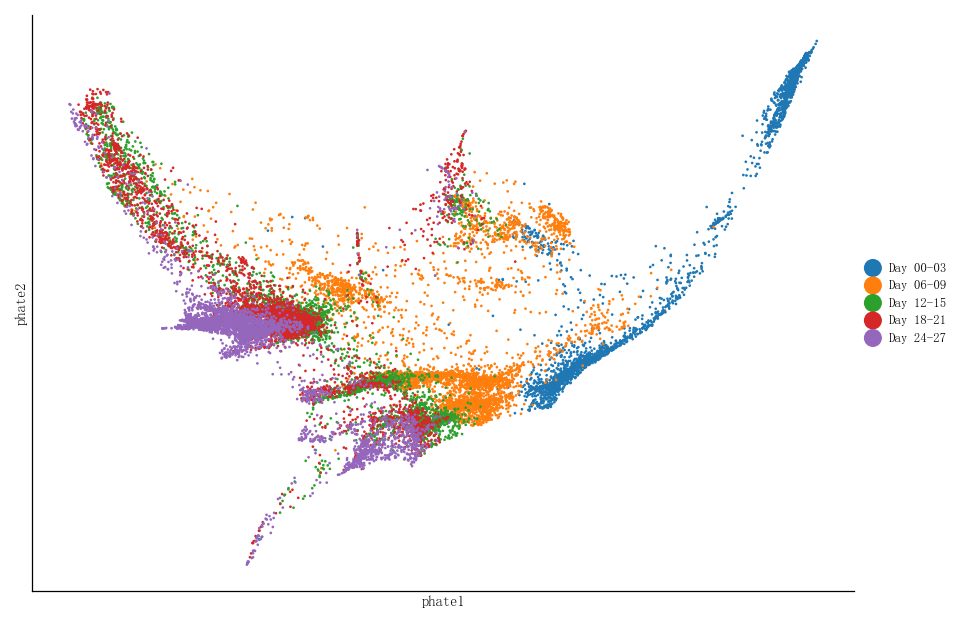

In [6]:
# phate降维后的图像
sc.pl.scatter(adata, basis="phate", color="sample_labels", title="")

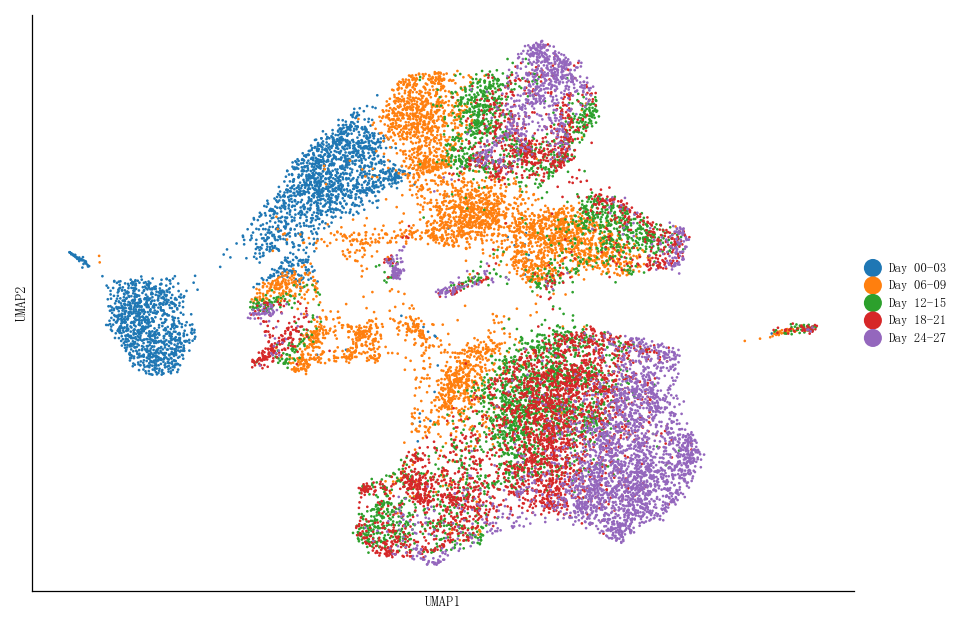

In [7]:
# umap降维
sc.pl.scatter(adata, basis="umap", color="sample_labels", title = "")


# phate可视化

In [8]:
# 加载OT-CFM模型
checkpoint = torch.load(
    r'D:\desktop\code\conditional-flow-matching\notes\experiment\models\ebdata phate\ot_cfm_single_cell.pt',
)
ot_cfm_model = checkpoint['model']


In [9]:
import scprep
def plot_trajectories(traj, legend=True):
    n = 1000
    
    # 使用模板中的尺寸
    fig, ax = plt.subplots(1, 1, figsize=DOUBLE_COLUMN) 
    
    # 背景 phate 
    scprep.plot.scatter( 
        adata.obsm["X_phate_standardized"][:, 0], 
        adata.obsm["X_phate_standardized"][:, 1], 
        c=adata.obs["sample_labels"], 
        ax=ax, 
        s=3, 
        alpha=0.6 
    ) 

    # 轨迹：使用模板中的灰色
    traj_line = ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.5, alpha=0.05, c=palette["light_gray"]) 
    
    # 起点：使用模板中的第一个颜色
    start_point = ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=7, alpha=0.9, c=palette["colors"][0]) 
    
    # 终点：使用模板中的第四个颜色
    end_point = ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=7, alpha=0.9, c=palette["colors"][3]) 

    # 图例对应 
    if legend: 
        ax.legend( 
            [start_point, traj_line, end_point], 
            ["初始样本点", "轨迹", "推断生成值"], 
            loc="best" 
        ) 

    plt.tight_layout() 
    # 使用模板中的导出函数
    #export_figure(fig, "trajectories", outdir="figures")
    plt.show()

In [10]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()

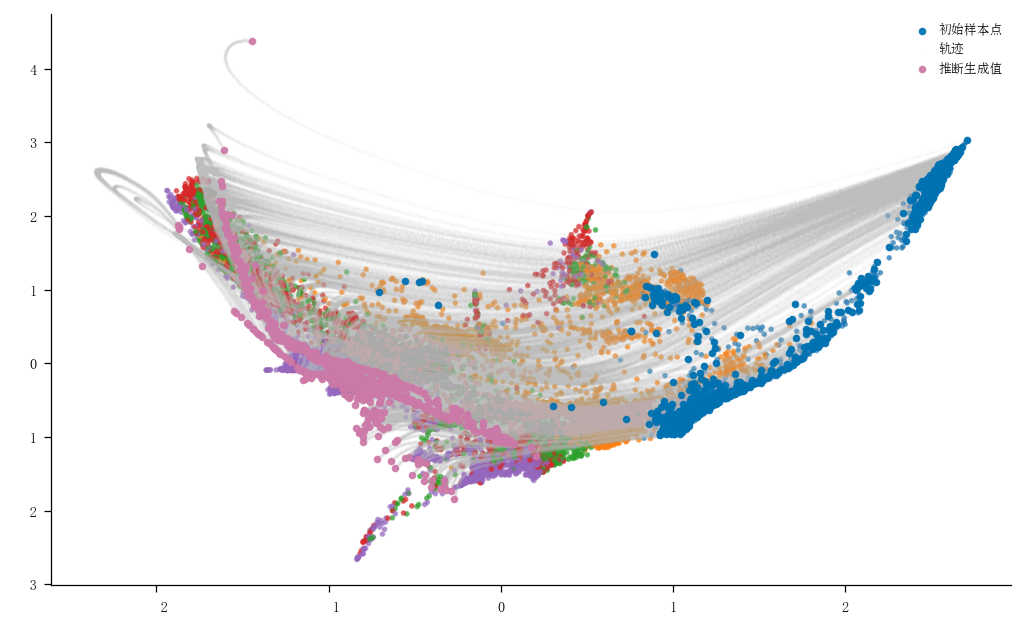

In [11]:
plot_trajectories(traj.cpu().numpy())

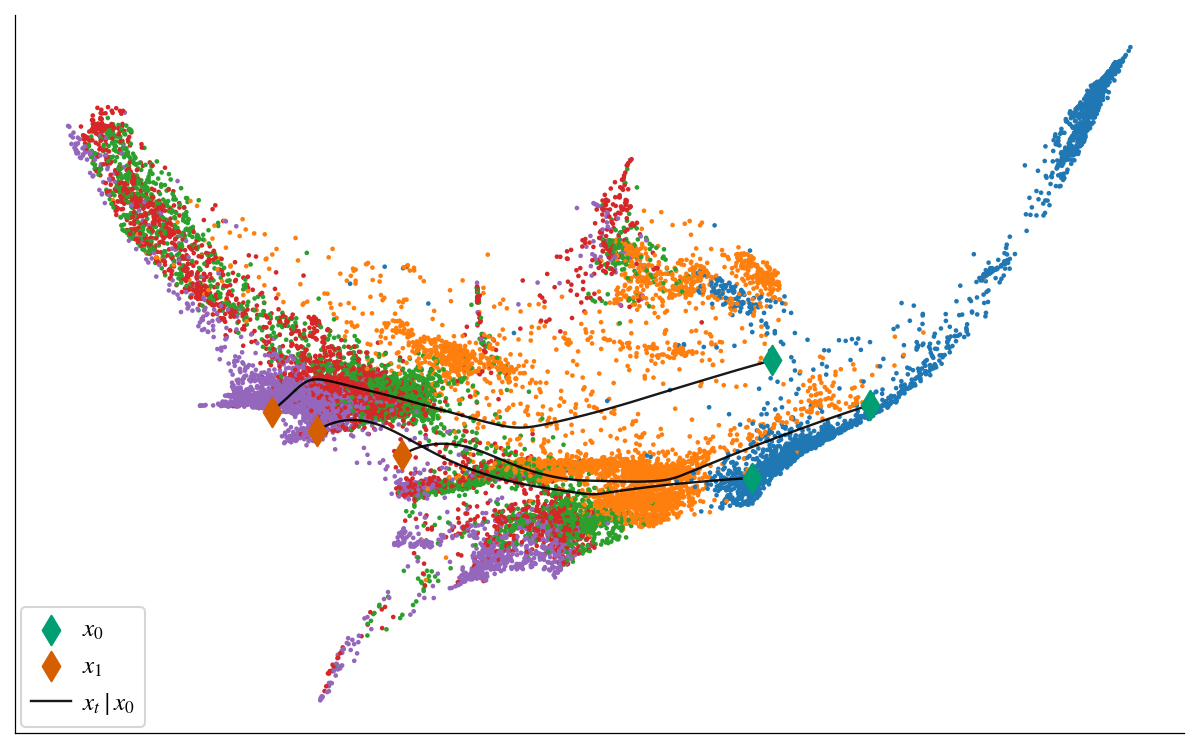

In [12]:
n = 3
# 只创建 1 个子图（左边那个）
f, ax1 = plt.subplots(1, 1, figsize=(8, 5))  # 修改这里

ax1.scatter(traj[0, 100:100+n, 0], traj[0, 100:100+n, 1], s=100, alpha=1, marker="d", c=palette["colors"][2], zorder=3)
ax1.scatter(traj[-1, 100:100+n, 0], traj[-1, 100:100+n, 1], s=100, alpha=1, marker="d", c=palette["colors"][4], zorder=3)

for i in range(3):
    ax1.plot(traj[:, 100+i, 0], traj[:, 100+i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax1,
    legend=None,
)

ax1.set_xticks([])
ax1.set_yticks([])
# ax1.set_title("Trajectories from given samples with POT-CFM", fontsize=15)
# ax1.set_title("POT-CFM从给定样本绘制的轨迹", fontsize=15)
ax1.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"], frameon=True, fancybox=True, fontsize=12)

plt.tight_layout()

# umap可视化

In [13]:
# n_times = 5,五个标签
n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
# 标准化坐标,分布为均值0方差1
coords = adata.obsm["X_umap"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_umap_standardized"] = coords
# X: 将坐标coords分为五个标签,每个标签含若干n_i个细胞,形状为 (5,n_i,2)
X_umap = [
    adata.obsm["X_umap_standardized"][adata.obs["sample_labels"].cat.codes == t]
    for t in range(n_times)
]

In [14]:

def plot_trajectories_umap(traj, legend=True):
    n = 500
    
    # 使用模板中的尺寸
    fig, ax = plt.subplots(1, 1, figsize=DOUBLE_COLUMN) 
    
    # 背景 umap 
    scprep.plot.scatter( 
        adata.obsm["X_umap_standardized"][:, 0], 
        adata.obsm["X_umap_standardized"][:, 1], 
        c=adata.obs["sample_labels"], 
        ax=ax, 
        s=3, 
        alpha=0.6 
    ) 

    # 轨迹：使用模板中的灰色
    traj_line = ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.5, alpha=0.05, c=palette["light_gray"]) 
    
    # 起点：使用模板中的第一个颜色
    start_point = ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=7, alpha=0.9, c=palette["colors"][0]) 
    
    # 终点：使用模板中的第四个颜色
    end_point = ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=7, alpha=0.9, c=palette["colors"][3]) 

    # 图例对应 
    if legend: 
        ax.legend( 
            [start_point, traj_line, end_point], 
            ["初始样本点", "轨迹", "推断生成值"], 
            loc="best" 
        ) 

    plt.tight_layout() 
    # 使用模板中的导出函数
    #export_figure(fig, "trajectories", outdir="figures")
    plt.show()

In [15]:
# 加载OT-CFM模型
checkpoint = torch.load(
    r'D:\desktop\code\conditional-flow-matching\notes\experiment\models\ebdata umap\ot_cfm_single_cell.pt',
)
ot_cfm_model_umap = checkpoint['model']
node = NeuralODE(torch_wrapper(ot_cfm_model_umap), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X_umap[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    

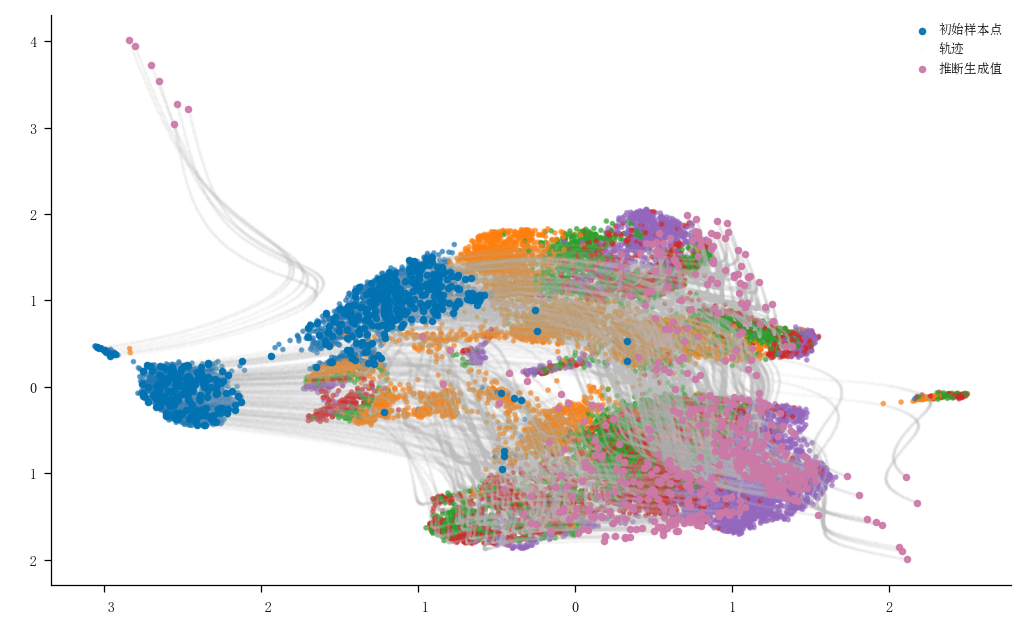

In [16]:
plot_trajectories_umap(traj.cpu().numpy())